El objetivo de este trabajo es aplicar un modelo de Regresión Lineal Múltiple para analizar si es posible predecir el precio de una vivienda a partir de distintas características.

Las variables utilizadas son:

- **m2:** superficie de la vivienda en metros cuadrados.
- **distance_center:** distancia de la vivienda al centro, expresada en kilómetros.
- **year:** antigüedad de la vivienda, expresada en años.
- **price:** precio de la vivienda, variable que se desea predecir.

### Pregunta de análisis

**¿Es posible predecir el precio de una vivienda a partir de su superficie, su distancia al centro y su antigüedad?**

In [3]:
import pandas as pd

In [2]:
import os
os.getcwd()

'C:\\Users\\veneg'

In [4]:
df = pd.read_csv("data/real_estate.csv")

In [5]:
df.head()

,m2,distance_center,year,price
0,129,1,13,8092000
1,75,1,28,1630000
2,106,14,13,6038000
3,101,4,13,5848000
4,117,11,23,5456000


In [6]:
df.shape

(2017, 4)

In [7]:
df.columns

Index(['m2', 'distance_center', 'year', 'price'], dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2017 entries, 0 to 2016
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   m2               2017 non-null   int64
 1   distance_center  2017 non-null   int64
 2   year             2017 non-null   int64
 3   price            2017 non-null   int64
dtypes: int64(4)
memory usage: 63.2 KB


In [9]:
df.describe()

,m2,distance_center,year,price
count,2017.000000,2017.000000,2017.000000,2.017000e+03
mean,108.463064,7.449678,15.053545,6.078621e+06
std,25.216793,4.566590,8.953313,2.379439e+06
min,65.000000,0.000000,0.000000,4.260000e+05
25%,86.000000,4.000000,7.000000,4.326000e+06
50%,110.000000,7.000000,15.000000,6.062000e+06
75%,130.000000,11.000000,23.000000,7.850265e+06
max,150.000000,15.000000,30.000000,1.245880e+07


In [10]:
df.corr()

,m2,distance_center,year,price
m2,1.000000,0.026922,0.029691,0.792626
distance_center,0.026922,1.000000,0.021879,-0.022582
year,0.029691,0.021879,1.000000,-0.520340
price,0.792626,-0.022582,-0.520340,1.000000


In [11]:
X = df[['m2', 'distance_center', 'year']]
y = df['price']

In [12]:
X.head()

,m2,distance_center,year
0,129,1,13
1,75,1,28
2,106,14,13
3,101,4,13
4,117,11,23


In [13]:
y.head()

0    8092000
1    1630000
2    6038000
3    5848000
4    5456000
Name: price, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [16]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1613, 3)
Datos de prueba: (404, 3)


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
modelo = LinearRegression()

In [19]:
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 76135.99, -16536.48,-143263.86]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['m2','distance_center','year']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.643e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [20]:
modelo.coef_

array([  76135.99480334,  -16536.4785463 , -143263.85693782])

In [21]:
modelo.intercept_

np.float64(96426.7705263393)

In [22]:
y_pred = modelo.predict(X_test)

In [23]:
y_pred[:5]

array([ 4278724.19138809,  9861330.15748315,  6421619.75663435,
        5386211.36955418, 10182894.72434995])

In [24]:
y_test.head()

1555     4214000
526      9988000
393      6434000
1788     5352000
433     10312000
Name: price, dtype: int64

In [25]:
from sklearn.metrics import r2_score

In [26]:
r2 = r2_score(y_test, y_pred)
r2

0.9621408810989263

In [27]:
from sklearn.metrics import mean_absolute_error

In [28]:
mae = mean_absolute_error(y_test, y_pred)
mae

105405.49205323006

In [29]:
from sklearn.metrics import mean_squared_error

In [30]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
rmse

465135.52137830964

In [31]:
import matplotlib.pyplot as plt

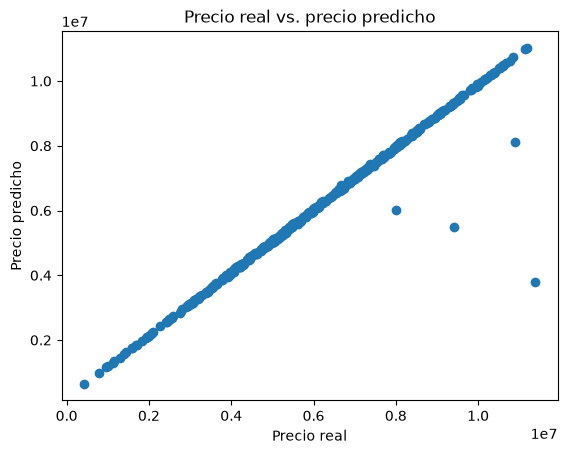

In [32]:
plt.scatter(y_test, y_pred)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Precio real vs. precio predicho")
plt.show()

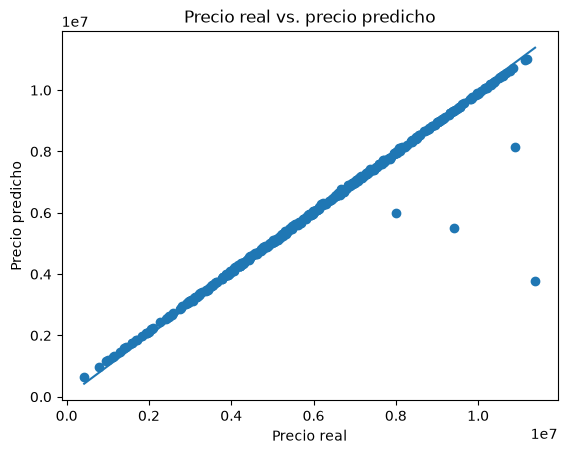

In [34]:
plt.scatter(y_test, y_pred)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Precio real vs. precio predicho")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [35]:
residuos = y_test - y_pred

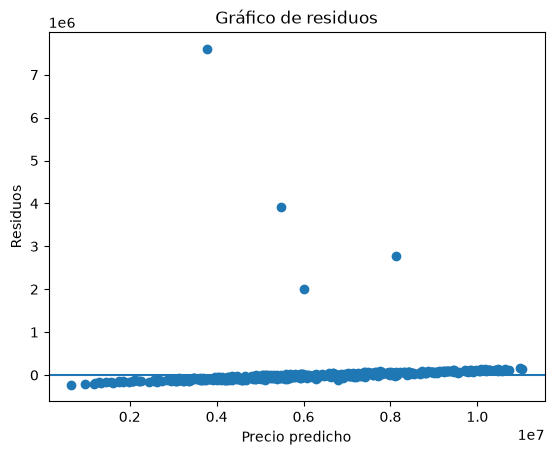

In [36]:
plt.scatter(y_pred, residuos)
plt.axhline(y=0)
plt.xlabel("Precio predicho")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos")
plt.show()

In [38]:
abs(residuos).sort_values(ascending=False).head()

1013    7.606072e+06
1078    3.916141e+06
938     2.766743e+06
1067    1.995969e+06
1830    2.255755e+05
Name: price, dtype: float64

In [39]:
df.loc[[1013, 1078, 938, 1067]]

,m2,distance_center,year,price
1013,98,12,25,11383792
1078,88,1,9,9406624
938,115,9,4,10896925
1067,105,5,14,7998299


## Conclusión

El modelo de Regresión Lineal Múltiple permitió estimar el precio de las viviendas a partir de su superficie, distancia al centro y antigüedad.

El modelo obtuvo un R² de 0,962, por lo que explica aproximadamente el 96,2 % de la variabilidad observada en los precios del conjunto de prueba. El MAE fue de aproximadamente 105.405 y el RMSE de 465.136.

Los gráficos muestran que la mayoría de las predicciones se encuentran próximas a los valores reales, aunque se identificaron algunos casos con errores elevados. Esto demuestra la importancia de complementar las métricas del modelo con el análisis visual de sus resultados.